In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np

IMG_SIZE = 128
data = []

dataset_path = "/content/drive/MyDrive/Train"

for patient in os.listdir(dataset_path):
    patient_path = os.path.join(dataset_path, patient)
    for img in os.listdir(patient_path):
        img_path = os.path.join(patient_path, img)
        image = cv2.imread(img_path)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image / 255.0
        data.append(image)

X = np.array(data)
print("Total images:", X.shape)


Total images: (3259, 128, 128, 3)


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(128,128,3))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2))(x)

# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.fit(
    X, X,
    epochs=20,
    batch_size=20,
    shuffle=True
)


Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - loss: 0.0470
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - loss: 0.0015
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - loss: 0.0010
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - loss: 7.7938e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - loss: 7.7259e-04
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - loss: 7.1439e-04
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - loss: 6.1074e-04
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - loss: 5.7568e-04
Epoch 9/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - loss: 5.6337e-04
Epoch 10/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - loss: 5.4373e-04
Epoch 11/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - loss: 5.2889e-04
Epoch 12/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - loss: 5.1492e-04
Epoch 13/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - loss: 4.6022e-04
Epoch 14/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - loss: 5.1558e-04

In [ ]:
encoder = Model(input_img, encoded)
features = encoder.predict(X)

features = features.reshape(features.shape[0], -1)


NameError: name 'X' is not defined

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(features)


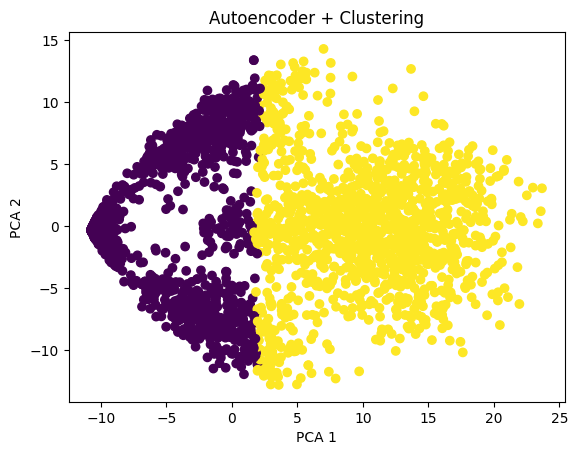

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(features)

plt.scatter(reduced[:,0], reduced[:,1], c=clusters, cmap='viridis')
plt.title("Autoencoder + Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [ ]:
import os
import cv2
import numpy as np

IMG_SIZE = 128
test_path = "/content/drive/MyDrive/Test"

test_images = []
test_names = []

for patient in os.listdir(test_path):
    p_path = os.path.join(test_path, patient)
    for img in os.listdir(p_path):
        img_path = os.path.join(p_path, img)
        image = cv2.imread(img_path)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image / 255.0
        test_images.append(image)
        test_names.append(patient)

X_test = np.array(test_images)
print("Test images:", X_test.shape)


Test images: (4010, 128, 128, 3)


In [ ]:
reconstructed = autoencoder.predict(X_test)

reconstruction_error = np.mean(
    np.square(X_test - reconstructed),
    axis=(1,2,3)
)


126/126 ━━━━━━━━━━━━━━━━━━━━ 79s 626ms/step


In [ ]:
threshold = np.mean(reconstruction_error) + np.std(reconstruction_error)

predictions = []
for err in reconstruction_error:
    if err > threshold:
        predictions.append("Abnormal")
    else:
        predictions.append("Normal")


In [ ]:
for i in range(2742):
    print(f"Patient: {test_names[i]} | Status: {predictions[i]}")


Patient: 1.3.6.1.4.1.9590.100.1.2.192996741813138389617212425101716524518 | Status: Normal
Patient: 1.3.6.1.4.1.9590.100.1.2.193291258211750389330909577073731175650 | Status: Normal
Patient: 1.3.6.1.4.1.9590.100.1.2.193291258211750389330909577073731175650 | Status: Abnormal
Patient: 1.3.6.1.4.1.9590.100.1.2.193183185811411930527046780454079660196 | Status: Abnormal
Patient: 1.3.6.1.4.1.9590.100.1.2.193183185811411930527046780454079660196 | Status: Normal
Patient: 1.3.6.1.4.1.9590.100.1.2.193276465510437956728991233890652097978 | Status: Normal
Patient: 1.3.6.1.4.1.9590.100.1.2.193276465510437956728991233890652097978 | Status: Abnormal
Patient: 1.3.6.1.4.1.9590.100.1.2.193209017912181210731137007683026874022 | Status: Normal
Patient: 1.3.6.1.4.1.9590.100.1.2.193217889712403095817239095663161018262 | Status: Normal
Patient: 1.3.6.1.4.1.9590.100.1.2.193217889712403095817239095663161018262 | Status: Abnormal
Patient: 1.3.6.1.4.1.9590.100.1.2.193074649312543779306115186273408108601 | Status

In [ ]:
import numpy as np

# Reconstruction for train
train_reconstructed = autoencoder.predict(X)
train_error = np.mean(np.square(X - train_reconstructed), axis=(1,2,3))
print("Average Train Reconstruction Error:", np.mean(train_error))

# Reconstruction for test
test_reconstructed = autoencoder.predict(X_test)
test_error = np.mean(np.square(X_test - test_reconstructed), axis=(1,2,3))
print("Average Test Reconstruction Error:", np.mean(test_error))


train_similarity = 100 - np.mean(train_error)*100
test_similarity = 100 - np.mean(test_error)*100

print(f"Train similarity: {train_similarity:.2f}%")
print(f"Test similarity: {test_similarity:.2f}%")



NameError: name 'autoencoder' is not defined